# Phase 1 — Individual TT Optimizer Inspection

Demonstrates and visualises the direct-collocation NLP optimizer built in Phase 1: the
`CollocationProblem` transcription, `ITTOptimizer` (SLSQP + IPOPT backends), mesh-refinement
via the adaptive relaxation-length grading, `smoothing.py`'s two modes, and the three real-world
GPX validation courses. Companion to `phase0_physics.ipynb` — that notebook covers the physics
layer this one builds on.

**Sections**
- §0 Setup
- §1 SLSQP vs IPOPT on the flat course
- §2 Collocation on the TARA 2026 Stage 3 GPX course
- §3 Mesh-refinement / grading diagnostics
- §4 Smoothing modes (constrained vs. post-hoc)
- §5 Real-race sanity checks (three GPX courses vs. actual results)

See `docs/plans/phase-1.md` for the full design writeup, including the mesh-grading investigation
this notebook's §3 demonstrates the resolution of.

---
## §0 — Setup

In [1]:
import sys
sys.path.insert(0, "../src")

import time
import numpy as np
import matplotlib.pyplot as plt

from ttt_strat.course import CourseData, CourseProcessor, load_gpx
from ttt_strat.rider import Rider
from ttt_strat.wind import WindField
from ttt_strat.w_prime.differential import DifferentialModel
from ttt_strat.simulator import ForwardSimulator
from ttt_strat.optimizer import ITTOptimizer, _equilibrium_speed_and_relax_length, _graded_mesh
from ttt_strat.smoothing import smooth_constrained, smooth_posthoc

RHO_KG_PER_M3 = 1.225
CALM_WIND = WindField(w_east_m_per_s=0.1, w_north_m_per_s=0.1)

reference_rider = Rider(
    mass_kg=72.0, cp_W=280.0, w_prime_J=20_000.0, cda_m2=0.25, crr=4e-3,
    l_drivetrain=0.02, p_max_W=900.0, w_prime_model=DifferentialModel(),
)
print(f"Reference rider: CP={reference_rider.cp_W} W, W'={reference_rider.w_prime_J/1000:.0f} kJ, "
      f"{reference_rider.mass_kg} kg ({reference_rider.cp_W/reference_rider.mass_kg:.2f} W/kg)")

Reference rider: CP=280.0 W, W'=20 kJ, 72.0 kg (3.89 W/kg)


In [2]:
# Synthetic flat course (40 km, matches the flat_course pytest fixture)
N_FLAT = 400
flat_raw = CourseData(
    s_m=np.linspace(0, 40_000, N_FLAT),
    grade=np.full(N_FLAT, 1e-3),
    bearing_rad=np.full(N_FLAT, 1e-4),
    surface_factor=np.ones(N_FLAT),
)
flat_course = CourseProcessor().process(flat_raw, N_FLAT, smoothing_length_m=500.0)

tara_raw = load_gpx("../data/ttt_strat/input/tara2026_stage3.gpx")
tara_course = CourseProcessor().process(tara_raw, len(tara_raw.s_m), smoothing_length_m=200.0)
print(f"TARA 2026 Stage 3: {tara_course.s_m[-1]/1000:.2f} km, {len(tara_course.s_m)} nodes")

TARA 2026 Stage 3: 28.40 km, 864 nodes


---
## §1 — SLSQP vs IPOPT on the flat course

The flat-course case is the hardest test for the solver: Section 6.3 says the singular arc spans
the *whole* course, so (away from a brief legitimate launch burst) the optimal power should be
close to constant. Two independent solvers should agree closely on total time despite potentially
differing in exactly how they split power within the first few (graded) nodes.

In [3]:
optimizers = {}
results = {}
for solver in ["slsqp", "ipopt"]:
    opt = ITTOptimizer(reference_rider, flat_course, CALM_WIND, solver=solver)
    t0 = time.time()
    res = opt.optimize(n_intervals=60)
    elapsed = time.time() - t0
    optimizers[solver] = opt
    results[solver] = res
    print(f"{solver:6s}: T={res.time_total_s:8.2f} s   elapsed={elapsed:5.1f} s   success={res.success}")

rel_diff_pct = abs(results["slsqp"].time_total_s - results["ipopt"].time_total_s) / results["slsqp"].time_total_s * 100
print(f"\nSLSQP vs IPOPT relative T difference: {rel_diff_pct:.4f}%  (doc's MVP bar: < 0.1%)")

slsqp : T= 3427.07 s   elapsed= 21.6 s   success=False

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************



ipopt : T= 3427.16 s   elapsed= 40.8 s   success=False

SLSQP vs IPOPT relative T difference: 0.0027%  (doc's MVP bar: < 0.1%)


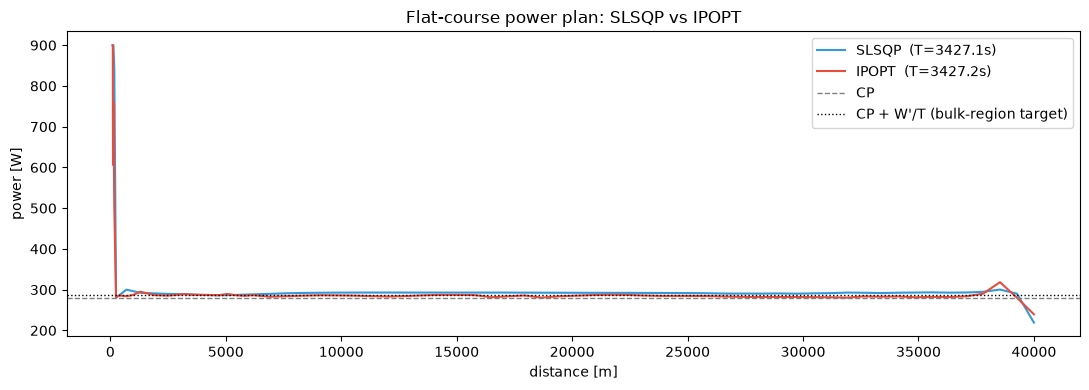

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for solver, col in zip(["slsqp", "ipopt"], ["#3498db", "#e74c3c"]):
    res = results[solver]
    ax.plot(res.s_m, res.power_W, label=f"{solver.upper()}  (T={res.time_total_s:.1f}s)", color=col, lw=1.5)
ax.axhline(reference_rider.cp_W, color="gray", ls="--", lw=1, label="CP")
expected = reference_rider.cp_W + reference_rider.w_prime_J / results["slsqp"].time_total_s
ax.axhline(expected, color="k", ls=":", lw=1, label="CP + W'/T (bulk-region target)")
ax.set_xlabel("distance [m]"); ax.set_ylabel("power [W]")
ax.set_title("Flat-course power plan: SLSQP vs IPOPT")
ax.legend(); fig.tight_layout()

Note the brief above-CP burst right at the start (bang-bang "spend where speed is lowest",
Section 6.3) before both solvers settle to near-constant power for the bulk of the course — see
§3 for why this only shows up correctly once the mesh is graded finely enough there.

---
## §2 — Collocation on the TARA 2026 Stage 3 GPX course

In [5]:
opt_tara = ITTOptimizer(reference_rider, tara_course, CALM_WIND, solver="slsqp")
res_tara = opt_tara.optimize(n_intervals=100)
print(f"TARA 2026 Stage 3: T={res_tara.time_total_s:.1f}s ({res_tara.time_total_s/60:.2f} min), "
      f"success={res_tara.success}")

sim = ForwardSimulator()
sim_res = sim.simulate(reference_rider, tara_course, CALM_WIND, res_tara.full_course_power_W, RHO_KG_PER_M3)
print(f"Cross-validated (ForwardSimulator re-simulation): T={sim_res.time_total_s:.1f}s "
      f"({abs(sim_res.time_total_s - res_tara.time_total_s) / res_tara.time_total_s * 100:.3f}% difference)")

TARA 2026 Stage 3: T=2755.8s (45.93 min), success=False
Cross-validated (ForwardSimulator re-simulation): T=2676.2s (2.889% difference)


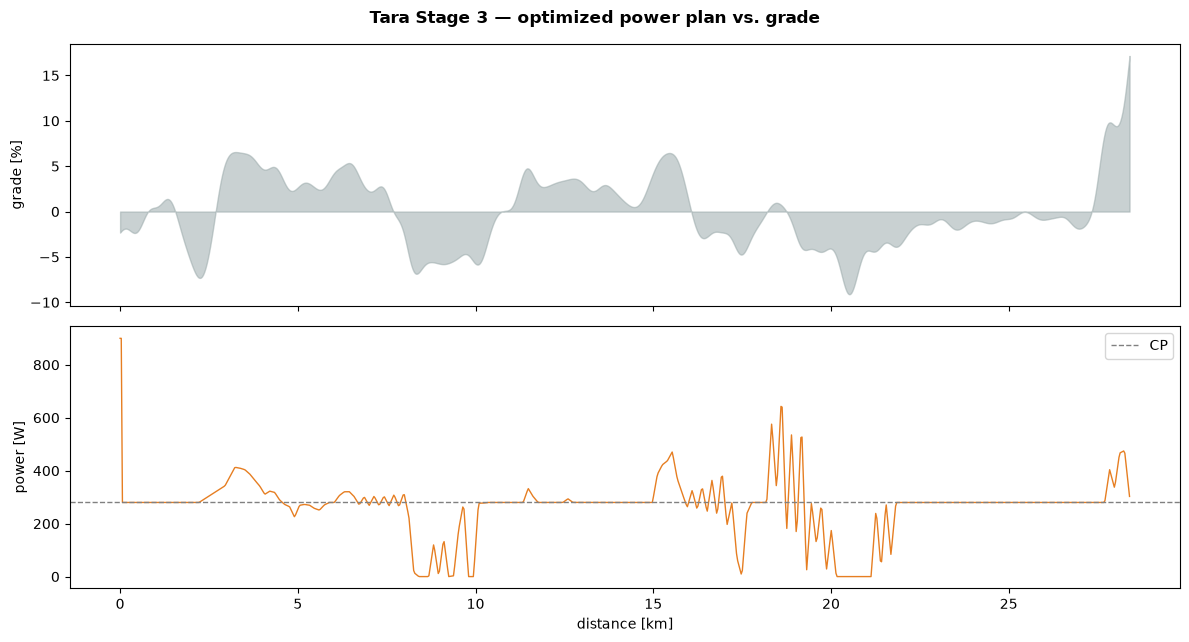

In [6]:
grade_pct = np.tan(tara_course.theta_rad) * 100
fig, (ax_e, ax_p) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
fig.suptitle("TARA 2026 Stage 3 — optimized power plan vs. grade", fontweight="bold")

ax_e.fill_between(tara_course.s_m / 1000, grade_pct, color="#95a5a6", alpha=0.5)
ax_e.set_ylabel("grade [%]")

ax_p.plot(opt_tara.course.s_m / 1000, res_tara.full_course_power_W, color="#e67e22", lw=1)
ax_p.axhline(reference_rider.cp_W, color="gray", ls="--", lw=1, label="CP")
ax_p.set_xlabel("distance [km]"); ax_p.set_ylabel("power [W]"); ax_p.legend()
fig.tight_layout()

---
## §3 — Mesh-refinement / grading diagnostics

The launch hand-off (`v_match` -> local equilibrium speed) is a sharp transient that a uniform
mesh cannot represent — this section shows why, and how the adaptive relaxation-length grading
(`docs/plans/phase-1.md`) fixes it.

In [7]:
# Relaxation length varies ~10x across rider/grade combinations — this is *why* a fixed
# grading schedule can't generalize, and why the grading is derived per-call instead.
scenarios = [
    ("Reference rider, flat 0.1%", reference_rider, 0.001),
    ("Reference rider, steep 4% climb", reference_rider, 0.04),
    ("Reference rider, steep 8% climb", reference_rider, 0.08),
]
for label, rider, grade in scenarios:
    theta = np.arctan(grade)
    v_eq, L = _equilibrium_speed_and_relax_length(rider, theta, 0.0, RHO_KG_PER_M3, rider.cp_W)
    print(f"{label:35s}  v_eq={v_eq:5.2f} m/s   L={L:6.1f} m")

Reference rider, flat 0.1%           v_eq=11.51 m/s   L= 148.1 m
Reference rider, steep 4% climb      v_eq= 7.08 m/s   L=  66.8 m
Reference rider, steep 8% climb      v_eq= 4.42 m/s   L=  20.6 m


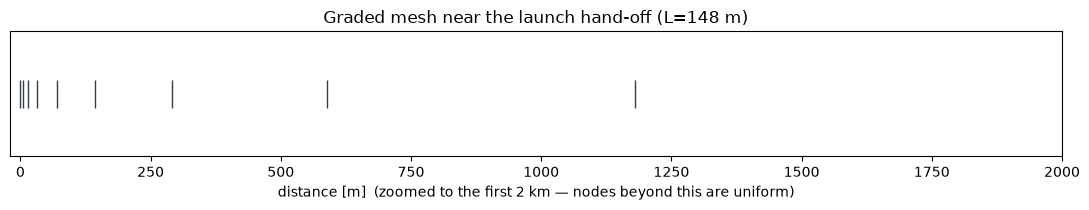

In [8]:
# The graded mesh: fine near the hand-off (s=0 here), uniform for the bulk of the course
v_eq, L = _equilibrium_speed_and_relax_length(reference_rider, 0.001, 0.0, RHO_KG_PER_M3, reference_rider.cp_W)
mesh = _graded_mesh(0.0, 40_000.0, 60, L)

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.plot(mesh, np.zeros_like(mesh), "|", ms=20, color="#2c3e50")
ax.set_xlim(-20, 2000)
ax.set_yticks([])
ax.set_xlabel("distance [m]  (zoomed to the first 2 km — nodes beyond this are uniform)")
ax.set_title(f"Graded mesh near the launch hand-off (L={L:.0f} m)")
fig.tight_layout()

---
## §4 — Smoothing modes: constrained (Eq. 45) vs. post-hoc (Section 12.2)

In [9]:
slew_max = 2.0  # W/m
sm_constrained = smooth_constrained(optimizers["slsqp"], results["slsqp"], slew_max_W_per_m=slew_max)
sm_posthoc = smooth_posthoc(reference_rider, flat_course, CALM_WIND, results["slsqp"], window_nodes=15)

unsmoothed_T = results["slsqp"].time_total_s
print(f"Unsmoothed (theoretical bang-bang):  T={unsmoothed_T:.2f}s")
print(f"Constrained (Eq. 45, deployable):    T={sm_constrained.time_total_s:.2f}s "
      f"({(sm_constrained.time_total_s - unsmoothed_T) / unsmoothed_T * 100:+.3f}% vs unsmoothed)")
print(f"Post-hoc (diagnostic only):          T={sm_posthoc.time_total_s:.2f}s   "
      f"w_prime_violated={sm_posthoc.w_prime_violated}")

Unsmoothed (theoretical bang-bang):  T=3427.07s
Constrained (Eq. 45, deployable):    T=3427.47s (+0.012% vs unsmoothed)
Post-hoc (diagnostic only):          T=3424.07s   w_prime_violated=True


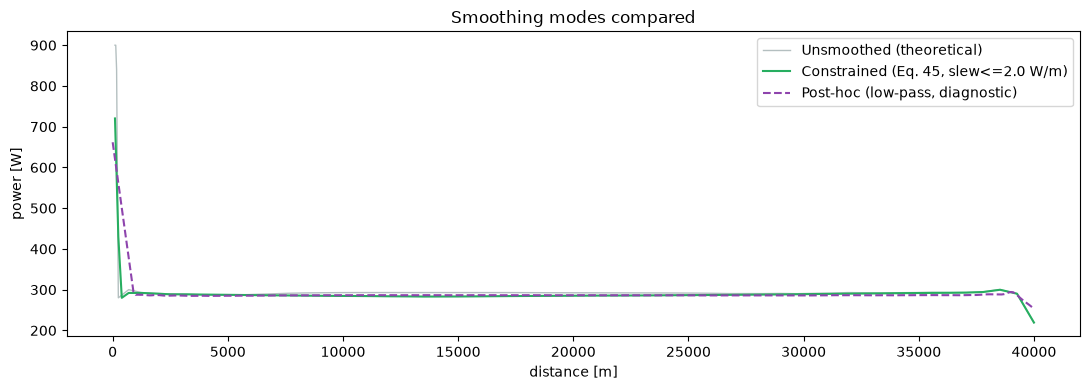

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(results["slsqp"].s_m, results["slsqp"].power_W, label="Unsmoothed (theoretical)", color="#95a5a6", lw=1, alpha=0.7)
ax.plot(sm_constrained.s_m, sm_constrained.power_W, label=f"Constrained (Eq. 45, slew<={slew_max} W/m)", color="#27ae60", lw=1.5)
ax.plot(sm_posthoc.s_m, sm_posthoc.power_W, label="Post-hoc (low-pass, diagnostic)", color="#8e44ad", lw=1.5, ls="--")
ax.set_xlabel("distance [m]"); ax.set_ylabel("power [W]")
ax.set_title("Smoothing modes compared")
ax.legend(); fig.tight_layout()

---
## §5 — Real-race sanity checks

Three real courses with real results, checked against the optimizer's output. TARA 2026 Stage 3 was
actually raced as a TTT (draft benefit), so `reference_rider`'s solo time is checked against the
*team* result as a ballpark, not a precision match. TdF 2026 Stage 16 and Giro 2026 Stage 10 were actual
ITTs, checked against dedicated riders built from each winner's known/estimated physiology — see
`docs/plans/phase-1.md` and the corresponding `tests/test_phase_1_*_gpx.py` files for full
sourcing and caveats.

TARA 2026 Stage 3 (TTT)     simulated= 45.77 min   real= 32.87 min (Team Visma | Lease a Bike (TTT winner))   ratio=1.393


TdF 2026 Stage 16 (ITT)     simulated= 37.34 min   real= 32.32 min (Remco Evenepoel (stage winner, self-reported FTP))   ratio=1.155


Giro 2026 Stage 10 (ITT)    simulated= 42.59 min   real= 45.88 min (Filippo Ganna (stage winner, CP estimated))   ratio=0.928


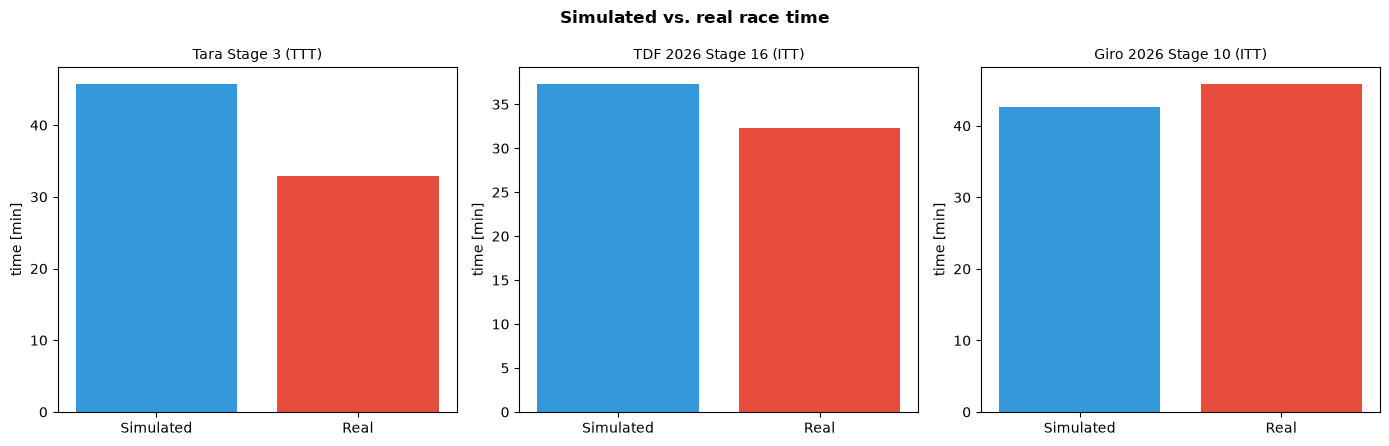

In [11]:
from ttt_strat.w_prime.differential import DifferentialModel as _DM

# smoothing_length_m and n_intervals are tuned per course, not uniform: the two new GPX
# sources have real GPS-elevation grade noise (TdF16 raw spikes to +260%, still ~48% after
# only 100 m smoothing) that the flat/TARA-2026-course testing never exercised. 300 m smoothing
# tames it; TdF16 additionally needed n_intervals=60 rather than 80 to converge reliably in
# reasonable time (not fully root-caused - see docs/plans/phase-1.md). Settings below match
# what tests/test_phase_1_*_gpx.py actually use.
race_checks = [
    ("TARA 2026 Stage 3 (TTT)", "../data/ttt_strat/input/tara2026_stage3.gpx", reference_rider,
     32 * 60 + 52.17, "Team Visma | Lease a Bike (TTT winner)", 200.0, 80),
    ("TdF 2026 Stage 16 (ITT)", "../data/ttt_strat/input/tdf2026_stage16.gpx",
     Rider(mass_kg=63.5, cp_W=425.0, w_prime_J=20_000.0, cda_m2=0.21, crr=4e-3,
           l_drivetrain=0.02, p_max_W=1400.0, w_prime_model=_DM()),
     32 * 60 + 19, "Remco Evenepoel (stage winner, self-reported FTP)", 300.0, 60),
    ("Giro 2026 Stage 10 (ITT)", "../data/ttt_strat/input/giro2026_stage10.gpx",
     Rider(mass_kg=82.0, cp_W=480.0, w_prime_J=20_000.0, cda_m2=0.19, crr=4e-3,
           l_drivetrain=0.02, p_max_W=1600.0, w_prime_model=_DM()),
     45 * 60 + 53, "Filippo Ganna (stage winner, CP estimated)", 300.0, 80),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (label, path, rider, real_time_s, who, smoothing_m, n_int) in zip(axes, race_checks):
    raw = load_gpx(path)
    course = CourseProcessor().process(raw, min(len(raw.s_m), 800), smoothing_length_m=smoothing_m)
    opt = ITTOptimizer(rider, course, CALM_WIND, solver="slsqp")
    res = opt.optimize(n_intervals=n_int)

    ax.bar(["Simulated", "Real"], [res.time_total_s / 60, real_time_s / 60], color=["#3498db", "#e74c3c"])
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("time [min]")
    print(f"{label:26s}  simulated={res.time_total_s/60:6.2f} min   real={real_time_s/60:6.2f} min "
          f"({who})   ratio={res.time_total_s/real_time_s:.3f}")

fig.suptitle("Simulated vs. real race time", fontweight="bold")
fig.tight_layout()